In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install tensorboardX rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 19.8 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data
torch.manual_seed(8) # for reproduce

import time
import numpy as np
import gc
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/code/')
sys.setrecursionlimit(50000)
import pickle
torch.backends.cudnn.benchmark = True
torch.set_default_tensor_type('torch.cuda.FloatTensor')
# from tensorboardX import SummaryWriter
torch.nn.Module.dump_patches = True
import copy
import pandas as pd
#then import my own modules
from AttentiveFP import Fingerprint, Fingerprint_viz, save_smiles_dicts, get_smiles_dicts, get_smiles_array, moltosvg_highlight



/usr/local/lib/python3.10/dist-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [ ]:
from rdkit import Chem
# from rdkit.Chem import AllChem
from rdkit.Chem import QED
from rdkit.Chem import rdMolDescriptors, MolSurf
from rdkit.Chem.Draw import SimilarityMaps
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
%matplotlib inline
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.cm as cm
import matplotlib
import seaborn as sns; sns.set_style("darkgrid")
from IPython.display import SVG, display
import sascorer
import itertools
from sklearn.metrics import r2_score
import scipy

In [ ]:
random_seed = 888 # 69, 88
start_time = str(time.ctime()).replace(':','-').replace(' ','_')

batch_size = 200
epochs = 200

p_dropout= 0.2
fingerprint_dim = 200

weight_decay = 5 # also known as l2_regularization_lambda
learning_rate = 2.5
output_units_num = 8 # for regression model
radius = 2
T = 4

# The original code blocks
Here we have the code in blocks for experimenting

number of successfully processed smiles:  40


<ipython-input-14-f7e59cfbdd4f>:36: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(atom_num_dist, bins=28, kde=False)


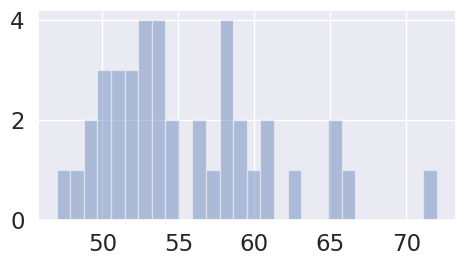

In [ ]:
#task_name = 'H3K4'
d

feature_filename = raw_filename.replace('.csv','.pickle')
filename = raw_filename.replace('.csv','')
prefix_filename = raw_filename.split('/')[-1].replace('.csv','')
smiles_tasks_df = pd.read_csv(raw_filename, sep= ",")


#smiles_tasks_df['H3K4']= smiles_tasks_df['Standard Value'].apply(np.log)

smilesList = smiles_tasks_df.SMILES.values
atom_num_dist = []
remained_smiles = []
canonical_smiles_list = []
for smiles in smilesList:
    try:
        mol = Chem.MolFromSmiles(smiles)
        atom_num_dist.append(len(mol.GetAtoms()))
        remained_smiles.append(smiles)
        canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
    except:
        print(smiles)
        pass
print("number of successfully processed smiles: ", len(remained_smiles))
smiles_tasks_df = smiles_tasks_df[smiles_tasks_df["SMILES"].isin(remained_smiles)]
# print(smiles_tasks_df)
smiles_tasks_df['cano_smiles'] =canonical_smiles_list
assert canonical_smiles_list[8]==Chem.MolToSmiles(Chem.MolFromSmiles(smiles_tasks_df['cano_smiles'][8]), isomericSmiles=True)

plt.figure(figsize=(5, 3))
sns.set(font_scale=1.5)
ax = sns.distplot(atom_num_dist, bins=28, kde=False)
plt.tight_layout()
# plt.savefig("atom_num_dist_"+prefix_filename+".png",dpi=200)
plt.show()
plt.close()


In [ ]:
if os.path.isfile(feature_filename):
    feature_dicts = pickle.load(open(feature_filename, "rb" ))
else:
    feature_dicts = save_smiles_dicts(smilesList,filename)
# feature_dicts = get_smiles_dicts(smilesList)
remained_df = smiles_tasks_df[smiles_tasks_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]
uncovered_df = smiles_tasks_df.drop(remained_df.index)
print("not processed items")
uncovered_df

not processed items


,Host,SMILES,H3K4,H3K4ac,H3K4me1,H3K4me2,H3K4me3,H3K9me3,H3R2me2a,H3R2me2s,cano_smiles


In [ ]:
remained_df = remained_df.reset_index(drop=True)
test_df = remained_df.sample(frac=1/10, random_state=random_seed) # test set
training_data = remained_df.drop(test_df.index) # training data

# training data is further divided into validation set and train set
valid_df = training_data.sample(frac=1/9, random_state=random_seed) # validation set
train_df = training_data.drop(valid_df.index) # train set
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# print(len(test_df),sorted(test_df.cano_smiles.values))


In [ ]:
x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array([canonical_smiles_list[0]],feature_dicts)
num_atom_features = x_atom.shape[-1]
num_bond_features = x_bonds.shape[-1]
loss_function = nn.MSELoss()
model = Fingerprint(radius, T, num_atom_features, num_bond_features,
            fingerprint_dim, output_units_num, p_dropout)
model.cuda()

# optimizer = optim.Adam(model.parameters(), learning_rate, weight_decay=weight_decay)
optimizer = optim.Adam(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)
# optimizer = optim.SGD(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)

# tensorboard = SummaryWriter(log_dir="runs/"+start_time+"_"+prefix_filename+"_"+str(fingerprint_dim)+"_"+str(p_dropout))

model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(params)
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data.shape)


865011
atom_fc.weight torch.Size([200, 39])
atom_fc.bias torch.Size([200])
neighbor_fc.weight torch.Size([200, 49])
neighbor_fc.bias torch.Size([200])
GRUCell.0.weight_ih torch.Size([600, 200])
GRUCell.0.weight_hh torch.Size([600, 200])
GRUCell.0.bias_ih torch.Size([600])
GRUCell.0.bias_hh torch.Size([600])
GRUCell.1.weight_ih torch.Size([600, 200])
GRUCell.1.weight_hh torch.Size([600, 200])
GRUCell.1.bias_ih torch.Size([600])
GRUCell.1.bias_hh torch.Size([600])
align.0.weight torch.Size([1, 400])
align.0.bias torch.Size([1])
align.1.weight torch.Size([1, 400])
align.1.bias torch.Size([1])
attend.0.weight torch.Size([200, 200])
attend.0.bias torch.Size([200])
attend.1.weight torch.Size([200, 200])
attend.1.bias torch.Size([200])
mol_GRUCell.weight_ih torch.Size([600, 200])
mol_GRUCell.weight_hh torch.Size([600, 200])
mol_GRUCell.bias_ih torch.Size([600])
mol_GRUCell.bias_hh torch.Size([600])
mol_align.weight torch.Size([1, 400])
mol_align.bias torch.Size([1])
mol_attend.weight torch.Si

In [ ]:
def train(model, dataset, optimizer, loss_function):
    model.train()
    np.random.seed(epoch)
    valList = np.arange(0,dataset.shape[0])
    #shuffle them
    np.random.shuffle(valList)
    batch_list = []
    for i in range(0, dataset.shape[0], batch_size):
        batch = valList[i:i+batch_size]
        batch_list.append(batch)
    for counter, train_batch in enumerate(batch_list):
        batch_df = dataset.loc[train_batch,:]
        smiles_list = batch_df.cano_smiles.values
        y_val = batch_df[tasks[0]].values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(smiles_list,feature_dicts)
        atoms_prediction, mol_prediction = model(torch.Tensor(x_atom),torch.Tensor(x_bonds),torch.cuda.LongTensor(x_atom_index),torch.cuda.LongTensor(x_bond_index),torch.Tensor(x_mask))

        model.zero_grad()

        loss = loss_function(mol_prediction, torch.Tensor(y_val).view(-1,1))
        loss.backward()
        optimizer.step()
def eval(model, dataset):
    model.eval()
    eval_MAE_list = []
    eval_MSE_list = []
    mol_predictions_list = []  # List to store predicted values
    y_val_list = []  # List to store actual values

    valList = np.arange(0, dataset.shape[0])
    batch_list = []
    for i in range(0, dataset.shape[0], batch_size):
        batch = valList[i:i+batch_size]
        batch_list.append(batch)

    for counter, eval_batch in enumerate(batch_list):
        batch_df = dataset.loc[eval_batch, :]
        smiles_list = batch_df.cano_smiles.values
        y_val = batch_df[tasks[0]].values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(smiles_list, feature_dicts)
        atoms_prediction, mol_prediction = model(torch.Tensor(x_atom), torch.Tensor(x_bonds), torch.cuda.LongTensor(x_atom_index), torch.cuda.LongTensor(x_bond_index), torch.Tensor(x_mask))

        MAE = F.l1_loss(mol_prediction, torch.Tensor(y_val).view(-1, 1), reduction='none')
        MSE = F.mse_loss(mol_prediction, torch.Tensor(y_val).view(-1,1), reduction='none')

        eval_MAE_list.extend(MAE.data.squeeze().cpu().numpy())
        eval_MSE_list.extend(MSE.data.squeeze().cpu().numpy())

        # Extending the predictions and actual values lists
        mol_predictions_list.extend(mol_prediction.data.squeeze().cpu().numpy())
        y_val_list.extend(y_val)

    # Convert lists to numpy arrays
    mol_predictions_array = np.array(mol_predictions_list)
    y_val_array = np.array(y_val_list)

    return np.array(eval_MAE_list).mean(), np.array(eval_MSE_list).mean(), mol_predictions_array, y_val_array



In [ ]:
import matplotlib.pyplot as plt

best_param ={}
best_param["train_epoch"] = 0
best_param["valid_epoch"] = 0
best_param["train_MSE"] = 9e8
best_param["valid_MSE"] = 9e8

for epoch in range(800):
    train_MAE, train_MSE, _, _ = eval(model, train_df)
    valid_MAE, valid_MSE, valid_pred, valid_act = eval(model, valid_df)
#     tensorboard.add_scalars('MAE',{'train_MAE':valid_MAE, 'test_MAE':valid_MSE}, epoch)
#     tensorboard.add_scalars('MSE',{'train_MSE':valid_MAE, 'test_MSE':valid_MSE}, epoch)
    if train_MSE < best_param["train_MSE"]:
        best_param["train_epoch"] = epoch
        best_param["train_MSE"] = train_MSE
    if valid_MSE < best_param["valid_MSE"]:
        best_param["valid_epoch"] = epoch
        best_param["valid_MSE"] = valid_MSE
        if valid_MSE < 3:
             print ('saved')
             torch.save(model, '/content/drive/MyDrive/Colab Notebooks/Drug_Project/AttentiveFP/code/saved_models/mod_'+prefix_filename+'_'+start_time+'_'+str(epoch)+'.pt')

    if (epoch - best_param["train_epoch"] >8) and (epoch - best_param["valid_epoch"] >18):
        print('break')
        break
    print(epoch, np.sqrt(train_MSE), np.sqrt(valid_MSE))

    train(model, train_df, optimizer, loss_function)


<ipython-input-51-c2f787a2b8f8>:45: UserWarning: Using a target size (torch.Size([4, 8])) that is different to the input size (torch.Size([32, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  MAE = F.l1_loss(mol_prediction, torch.Tensor(y_val).view(-1, 8), reduction='none')


RuntimeError: ignored

<ipython-input-18-9a651036f916>:44: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  MAE = F.l1_loss(mol_prediction, torch.Tensor(y_val).view(-1, 1), reduction='none')
<ipython-input-18-9a651036f916>:45: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  MSE = F.mse_loss(mol_prediction, torch.Tensor(y_val).view(-1, 1), reduction='none')
<ipython-input-18-9a651036f916>:44: UserWarning: Using a target size (torch.Size([4, 1])) that is different to the input size (torch.Size([4, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  MAE = F.l1_loss(mol_prediction, torch.Tensor(y_val).view(-1, 1), reduc

ValueError: ignored

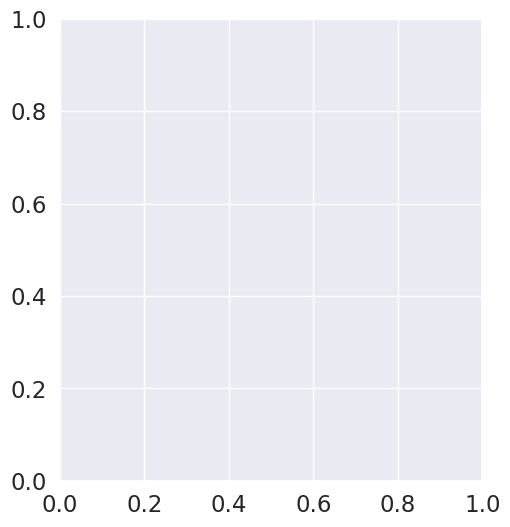

In [ ]:

import matplotlib.pyplot as plt

# evaluate model
best_model = torch.load('/content/drive/MyDrive/Colab Notebooks/Drug_Project/AttentiveFP/code/saved_models/mod_'+prefix_filename+'_'+start_time+'_'+str(best_param["valid_epoch"])+'.pt')

best_model_dict = best_model.state_dict()
best_model_wts = copy.deepcopy(best_model_dict)

model.load_state_dict(best_model_wts)
(best_model.align[0].weight == model.align[0].weight).all()

# Evaluate on both training and validation datasets
train_MAE, train_MSE, train_pred, train_act = eval(model, train_df)
valid_MAE, valid_MSE, valid_pred, valid_act = eval(model, valid_df)

# Plotting the actual vs predicted values side by side for training and validation datasets
plt.figure(figsize=(12,6))

# Train data
plt.subplot(1, 2, 1)
plt.scatter(train_act, train_pred, alpha=0.5)
plt.plot([min(train_act), max(train_act)], [min(train_act), max(train_act)], color='red')
plt.title(f'Train Data for Best Model')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Validation data
plt.subplot(1, 2, 2)
plt.scatter(valid_act, valid_pred, alpha=0.5)
plt.plot([min(valid_act), max(valid_act)], [min(valid_act), max(valid_act)], color='red')
plt.title(f'Validation Data for Best Model')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.tight_layout()
plt.show()

print("best epoch:", best_param["valid_epoch"])
print("train RMSE:", np.sqrt(train_MSE))
print("validation RMSE:", np.sqrt(valid_MSE))



In [ ]:
file = '/content/drive/MyDrive/Colab Notebooks/Drug_Project/AttentiveFP/code/saved_models/mod'+prefix_filename+'_'+start_time+'_'+str(best_param["valid_epoch"])+'.txt'

open(file, 'a').close()

#All together.
All the code in one block to go through all the datasets.

number of successfully processed smiles:  173


<ipython-input-46-0b8a8fad2ec1>:38: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(atom_num_dist, bins=28, kde=False)


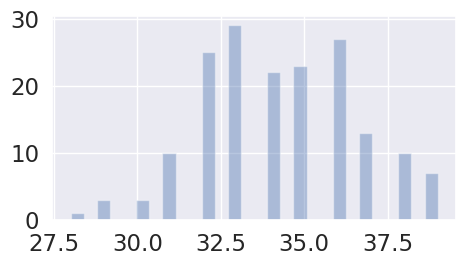

Streaming output truncated to the last 5000 lines.
       [24., 25., 42., 42., 42., 42.],
       [25., 26., 42., 42., 42., 42.],
       [26., 27., 42., 42., 42., 42.],
       [ 1.,  2.,  3., 42., 42., 42.],
       [ 4.,  5., 30., 42., 42., 42.],
       [ 6.,  7., 31., 42., 42., 42.],
       [ 7.,  8., 17., 42., 42., 42.],
       [ 9., 10., 32., 42., 42., 42.],
       [12., 13., 14., 42., 42., 42.],
       [15., 16., 32., 42., 42., 42.],
       [20., 21., 31., 42., 42., 42.],
       [22., 23., 30., 42., 42., 42.],
       [27., 28., 29., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.],
       [42., 42., 42., 42., 42., 42.]]), 'C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNCC(C)=O': array([[ 0., 42., 42., 42., 42., 42

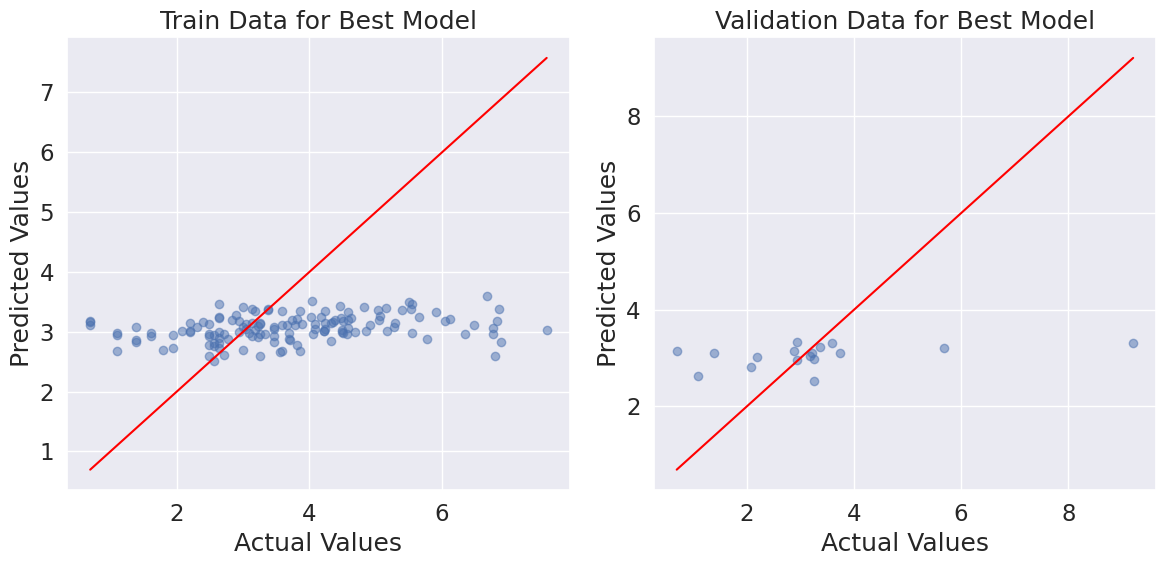

best epoch: 111
train RMSE: 1.5599967
validation RMSE: 1.7942232
number of successfully processed smiles:  1017


<ipython-input-46-0b8a8fad2ec1>:38: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(atom_num_dist, bins=28, kde=False)


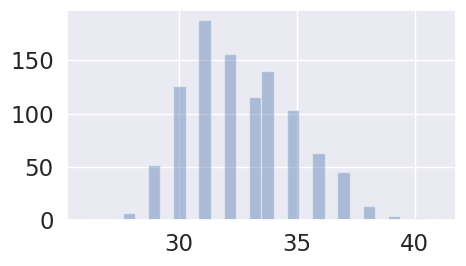

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



1 3.8747163 4.135543
2 2.517599 2.658741
3 2.5321727 2.7023199
4 2.5478857 2.7251525
5 2.502511 2.6231575
6 2.5279884 2.6237178
7 2.5068893 2.6666977
8 2.5122762 2.676506
9 2.4819968 2.6175818
10 2.4915655 2.5978656
11 2.4737284 2.591567
12 2.46558 2.6113064
13 2.4454055 2.5774825
14 2.4153402 2.5468843
15 2.3563724 2.4572763
16 2.2226946 2.2765098
saved
17 2.0917714 2.054792
18 3.5184314 3.4524992
19 2.614262 2.8148813
20 2.5422566 2.7268844
21 2.423004 2.5343506
22 2.4125884 2.510759
23 2.368535 2.481925
24 2.3308444 2.4334865
25 2.3137195 2.3845212
26 2.2258606 2.320655
27 2.1634462 2.2109785
28 2.1148381 2.1621606
29 2.0707488 2.078649
30 2.353085 2.4142354
31 2.1306663 2.132343
32 2.05933 2.126773
33 2.0512285 2.0863564
34 2.0210795 2.0785358
35 2.0563085 2.0674992
saved
36 2.001029 2.042747
saved
37 1.9730898 1.9687551
saved
38 1.9536655 1.9679102
39 2.0793447 2.0438154
40 1.9737445 2.0353203
41 1.9698542 1.9867913
saved
42 1.9178232 1.9315012
43 1.908274 1.9329299
saved
44 1.928

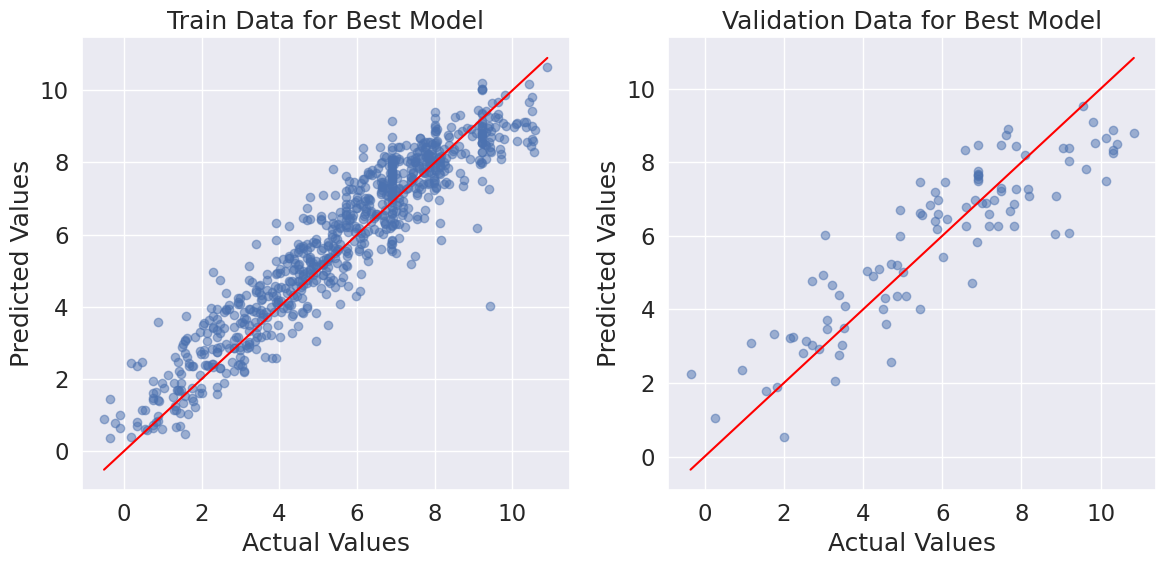

best epoch: 229
train RMSE: 0.8832713
validation RMSE: 1.2380798
number of successfully processed smiles:  357


<ipython-input-46-0b8a8fad2ec1>:38: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(atom_num_dist, bins=28, kde=False)


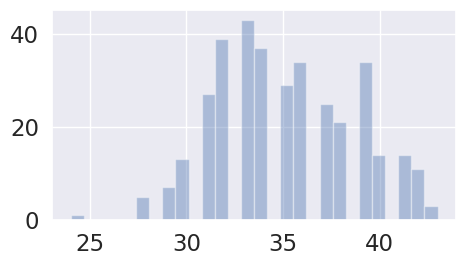

feature dicts file saved as /content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/data/357_len.pickle
False
not processed items
863604
atom_fc.weight torch.Size([200, 39])
atom_fc.bias torch.Size([200])
neighbor_fc.weight torch.Size([200, 49])
neighbor_fc.bias torch.Size([200])
GRUCell.0.weight_ih torch.Size([600, 200])
GRUCell.0.weight_hh torch.Size([600, 200])
GRUCell.0.bias_ih torch.Size([600])
GRUCell.0.bias_hh torch.Size([600])
GRUCell.1.weight_ih torch.Size([600, 200])
GRUCell.1.weight_hh torch.Size([600, 200])
GRUCell.1.bias_ih torch.Size([600])
GRUCell.1.bias_hh torch.Size([600])
align.0.weight torch.Size([1, 400])
align.0.bias torch.Size([1])
align.1.weight torch.Size([1, 400])
align.1.bias torch.Size([1])
attend.0.weight torch.Size([200, 200])
attend.0.bias torch.Size([200])
attend.1.weight torch.Size([200, 200])
attend.1.bias torch.Size([200])
mol_GRUCell.weight_ih torch.Size([600, 200])
mol_GRUCell.weight_hh torch.Size([600, 200])
mol_GRUCell.bias_ih torch.Size([60

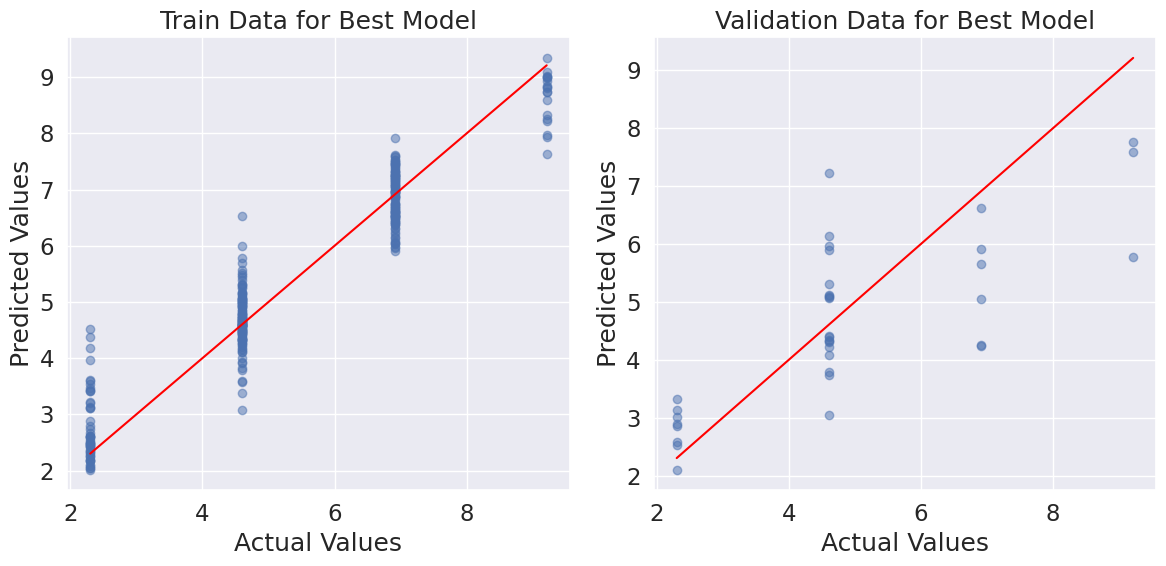

best epoch: 339
train RMSE: 0.5687386
validation RMSE: 1.2744541
number of successfully processed smiles:  363


<ipython-input-46-0b8a8fad2ec1>:38: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(atom_num_dist, bins=28, kde=False)


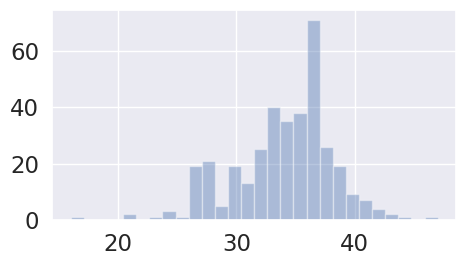

feature dicts file saved as /content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/data/363_len.pickle
False
not processed items
863604
atom_fc.weight torch.Size([200, 39])
atom_fc.bias torch.Size([200])
neighbor_fc.weight torch.Size([200, 49])
neighbor_fc.bias torch.Size([200])
GRUCell.0.weight_ih torch.Size([600, 200])
GRUCell.0.weight_hh torch.Size([600, 200])
GRUCell.0.bias_ih torch.Size([600])
GRUCell.0.bias_hh torch.Size([600])
GRUCell.1.weight_ih torch.Size([600, 200])
GRUCell.1.weight_hh torch.Size([600, 200])
GRUCell.1.bias_ih torch.Size([600])
GRUCell.1.bias_hh torch.Size([600])
align.0.weight torch.Size([1, 400])
align.0.bias torch.Size([1])
align.1.weight torch.Size([1, 400])
align.1.bias torch.Size([1])
attend.0.weight torch.Size([200, 200])
attend.0.bias torch.Size([200])
attend.1.weight torch.Size([200, 200])
attend.1.bias torch.Size([200])
mol_GRUCell.weight_ih torch.Size([600, 200])
mol_GRUCell.weight_hh torch.Size([600, 200])
mol_GRUCell.bias_ih torch.Size([60

FileNotFoundError: ignored

In [ ]:
data_list= [173, 1017, 357, 363, 368, 449, 460, 482, 589, 621, 626, 627, 634, 641, 663, 731, 732, 744,752,834]
valids=[]

for i in data_list:

  raw_filename = str('/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/data/cal_abs.csv')

  feature_filename = raw_filename.replace('.csv','.pickle')
  filename = raw_filename.replace('.csv','')
  prefix_filename = raw_filename.split('/')[-1].replace('.csv','')
  smiles_tasks_df = pd.read_csv(raw_filename, sep= ";")


  smiles_tasks_df['IC50']= smiles_tasks_df['Standard Value'].apply(np.log)

  smilesList = smiles_tasks_df.Smiles.values
  #print("number of all smiles: ",len(smilesList))
  atom_num_dist = []
  remained_smiles = []
  canonical_smiles_list = []
  for smiles in smilesList:
      try:
          mol = Chem.MolFromSmiles(smiles)
          atom_num_dist.append(len(mol.GetAtoms()))
          remained_smiles.append(smiles)
          canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
      except:
          print(smiles)
          pass
  print("number of successfully processed smiles: ", len(remained_smiles))
  smiles_tasks_df = smiles_tasks_df[smiles_tasks_df["Smiles"].isin(remained_smiles)]
  # print(smiles_tasks_df)
  smiles_tasks_df['cano_smiles'] =canonical_smiles_list
  assert canonical_smiles_list[8]==Chem.MolToSmiles(Chem.MolFromSmiles(smiles_tasks_df['cano_smiles'][8]), isomericSmiles=True)

  plt.figure(figsize=(5, 3))
  sns.set(font_scale=1.5)
  ax = sns.distplot(atom_num_dist, bins=28, kde=False)
  plt.tight_layout()
  # plt.savefig("atom_num_dist_"+prefix_filename+".png",dpi=200)
  plt.show()
  plt.close()



  if os.path.isfile(feature_filename):
      feature_dicts = pickle.load(open(feature_filename, "rb" ))
      print(feature_dicts)
  else:
      feature_dicts = save_smiles_dicts(smilesList,filename)
      print(False)
  # feature_dicts = get_smiles_dicts(smilesList)
  remained_df = smiles_tasks_df[smiles_tasks_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]
  uncovered_df = smiles_tasks_df.drop(remained_df.index)
  print("not processed items")
  uncovered_df

  remained_df = remained_df.reset_index(drop=True)
  test_df = remained_df.sample(frac=1/10, random_state=random_seed) # test set
  training_data = remained_df.drop(test_df.index) # training data

  # training data is further divided into validation set and train set
  valid_df = training_data.sample(frac=1/9, random_state=random_seed) # validation set
  train_df = training_data.drop(valid_df.index) # train set
  train_df = train_df.reset_index(drop=True)
  valid_df = valid_df.reset_index(drop=True)
  test_df = test_df.reset_index(drop=True)

  # print(len(test_df),sorted(test_df.cano_smiles.values))



  x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array([canonical_smiles_list[0]],feature_dicts)
  num_atom_features = x_atom.shape[-1]
  num_bond_features = x_bonds.shape[-1]
  loss_function = nn.MSELoss()
  model = Fingerprint(radius, T, num_atom_features, num_bond_features,
              fingerprint_dim, output_units_num, p_dropout)
  model.cuda()

  # optimizer = optim.Adam(model.parameters(), learning_rate, weight_decay=weight_decay)
  optimizer = optim.Adam(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)
  # optimizer = optim.SGD(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)

  # tensorboard = SummaryWriter(log_dir="runs/"+start_time+"_"+prefix_filename+"_"+str(fingerprint_dim)+"_"+str(p_dropout))

  model_parameters = filter(lambda p: p.requires_grad, model.parameters())
  params = sum([np.prod(p.size()) for p in model_parameters])
  print(params)
  for name, param in model.named_parameters():
      if param.requires_grad:
          print(name, param.data.shape)




  best_param ={}
  best_param["train_epoch"] = 0
  best_param["valid_epoch"] = 0
  best_param["train_MSE"] = 9e8
  best_param["valid_MSE"] = 9e8

  for epoch in range(800):
      train_MAE, train_MSE, _, _ = eval(model, train_df)
      valid_MAE, valid_MSE, valid_pred, valid_act = eval(model, valid_df)
  #     tensorboard.add_scalars('MAE',{'train_MAE':valid_MAE, 'test_MAE':valid_MSE}, epoch)
  #     tensorboard.add_scalars('MSE',{'train_MSE':valid_MAE, 'test_MSE':valid_MSE}, epoch)
      if train_MSE < best_param["train_MSE"]:
          best_param["train_epoch"] = epoch
          best_param["train_MSE"] = train_MSE
      if valid_MSE < best_param["valid_MSE"]:
          best_param["valid_epoch"] = epoch
          best_param["valid_MSE"] = valid_MSE
          if valid_MSE < 4.41:
              print ('saved')
              torch.save(model, '/content/drive/MyDrive/Colab Notebooks/Drug_Project/AttentiveFP/code/saved_models/mod_'+prefix_filename+'_'+start_time+'_'+str(epoch)+'.pt')

      if (epoch - best_param["train_epoch"] >8) and (epoch - best_param["valid_epoch"] >18):
          print('break')
          break
      print(epoch, np.sqrt(train_MSE), np.sqrt(valid_MSE))

      train(model, train_df, optimizer, loss_function)


  file = '/content/drive/MyDrive/Colab Notebooks/Drug_Project/AttentiveFP/code/saved_models/mod'+prefix_filename+'_'+start_time+'_'+str(best_param["valid_epoch"])+'.txt'

  open(file, 'a').close()



  import matplotlib.pyplot as plt

  # evaluate model
  best_model = torch.load('/content/drive/MyDrive/Colab Notebooks/Drug_Project/AttentiveFP/code/saved_models/mod_'+prefix_filename+'_'+start_time+'_'+str(best_param["valid_epoch"])+'.pt')

  best_model_dict = best_model.state_dict()
  best_model_wts = copy.deepcopy(best_model_dict)

  model.load_state_dict(best_model_wts)
  (best_model.align[0].weight == model.align[0].weight).all()

  # Evaluate on both training and validation datasets
  train_MAE, train_MSE, train_pred, train_act = eval(model, train_df)
  valid_MAE, valid_MSE, valid_pred, valid_act = eval(model, valid_df)

  # Plotting the actual vs predicted values side by side for training and validation datasets
  plt.figure(figsize=(12,6))

  # Train data
  plt.subplot(1, 2, 1)
  plt.scatter(train_act, train_pred, alpha=0.5)
  plt.plot([min(train_act), max(train_act)], [min(train_act), max(train_act)], color='red')
  plt.title(f'Train Data for Best Model')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Validation data
  plt.subplot(1, 2, 2)
  plt.scatter(valid_act, valid_pred, alpha=0.5)
  plt.plot([min(valid_act), max(valid_act)], [min(valid_act), max(valid_act)], color='red')
  plt.title(f'Validation Data for Best Model')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  plt.tight_layout()
  plt.show()

  print("best epoch:", best_param["valid_epoch"])
  print("train RMSE:", np.sqrt(train_MSE))
  print("validation RMSE:", np.sqrt(valid_MSE))
  valids.append(np.sqrt(valid_MSE))

In [ ]:
valids

[1.8560687, 1.2995814]

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your dictionary
dis = {
    "284": {"TRMSE": 12, "VRMSE": 12},
    "177": {"TRMSE": 13, "VRMSE": 15},
    "500": {"TRMSE": 20, "VRMSE": 21}
}

# Transforming the dictionary into a DataFrame
data = []
for size, rmse_values in dis.items():
    for rmse_type, value in rmse_values.items():
        data.append({'Size': size, 'RMSE_Type': rmse_type, 'Value': value})

df = pd.DataFrame(data)


# Create the violin plot
sns.violinplot(x="Size", y="Value", hue="RMSE_Type", data=df, split=True)

# Additional styling if needed
plt.title('Violin plot of RMSEs by Size')
plt.xlabel('Size')
plt.ylabel('RMSE Value')

# Show the plot
plt.show()


ValueError: ignored